Severity-weighted equalisation of the central police grant

In [1]:
import polars as pl

In [2]:
settlement = pl.DataFrame(
    [
        ("Avon and Somerset", 231_607_316, 177_637_987),
        ("Bedfordshire", 89_796_074, 66_153_261),
        ("Cambridgeshire", 104_239_821, 92_986_426),
        ("Cheshire", 150_680_231, 111_918_516),
        ("Cleveland", 121_078_242, 52_667_814),
        ("Cumbria", 84_899_111, 61_513_817),
        ("Derbyshire", 142_436_827, 100_481_115),
        ("Devon and Cornwall", 238_109_971, 192_241_234),
        ("Dorset", 86_023_913, 96_077_903),
        ("Durham", 112_902_355, 52_119_878),
        ("Essex", 226_496_040, 176_905_154),
        ("Gloucestershire", 78_049_635, 79_577_977),
        ("Hampshire", 258_895_787, 200_746_599),
        ("Hertfordshire", 155_245_239, 124_356_129),
        ("Humberside", 162_844_543, 86_855_887),
        ("Kent", 245_418_856, 183_707_973),
        ("Lancashire", 253_239_560, 130_877_615),
        ("Leicestershire", 149_398_893, 105_066_901),
        ("Lincolnshire", 85_506_516, 78_903_586),
        ("Merseyside", 331_638_676, 111_273_380),
        ("Metropolitan Police", 2_293_667_499, 1_028_389_503),
        ("Norfolk", 115_480_008, 106_874_038),
        ("North Yorkshire", 99_967_235, 104_032_909),
        ("Northamptonshire", 96_686_118, 84_405_845),
        ("Northumbria", 300_591_884, 82_884_762),
        ("Nottinghamshire", 178_948_808, 101_019_090),
        ("South Yorkshire", 250_092_807, 100_125_232),
        ("Staffordshire", 154_682_190, 106_273_773),
        ("Suffolk", 92_286_811, 79_830_318),
        ("Surrey", 132_132_164, 177_764_497),
        ("Sussex", 216_775_293, 177_339_747),
        ("Thames Valley", 304_039_970, 278_885_731),
        ("Warwickshire", 70_314_436, 68_851_113),
        ("West Mercia", 159_104_841, 137_997_657),
        ("West Midlands", 598_077_146, 175_423_018),
        ("West Yorkshire", 420_762_883, 182_552_185),
        ("Wiltshire", 82_937_470, 77_635_922),
        ("City of London", 68_842_409, None),
        ("Dyfed-Powys", 38_930_060, 93_032_816),
        ("Gwent", 58_261_643, 93_286_501),
        ("North Wales", 56_384_956, 122_962_611),
        ("South Wales", 135_114_023, 211_664_158),
    ],
    schema=["force", "grant", "precept"], orient="row",
)

In [3]:
# fix canonical names, not the same as the force names in the forecast data
FORCE_NAME = {
    "Avon and Somerset Constabulary": "Avon and Somerset",
    "Bedfordshire Police": "Bedfordshire",
    "Cambridgeshire Constabulary": "Cambridgeshire",
    "Cheshire Constabulary": "Cheshire",
    "City of London Police": "City of London",
    "Cleveland Police": "Cleveland",
    "Cumbria Constabulary": "Cumbria",
    "Derbyshire Constabulary": "Derbyshire",
    "Devon & Cornwall Police": "Devon and Cornwall",
    "Dorset Police": "Dorset",
    "Durham Constabulary": "Durham",
    "Dyfed-Powys Police": "Dyfed-Powys",
    "Essex Police": "Essex",
    "Gloucestershire Constabulary": "Gloucestershire",
    "Gwent Police": "Gwent",
    "Hampshire Constabulary": "Hampshire",
    "Hertfordshire Constabulary": "Hertfordshire",
    "Humberside Police": "Humberside",
    "Kent Police": "Kent",
    "Lancashire Constabulary": "Lancashire",
    "Leicestershire Police": "Leicestershire",
    "Lincolnshire Police": "Lincolnshire",
    "Merseyside Police": "Merseyside",
    "Metropolitan Police Service": "Metropolitan Police",
    "Norfolk Constabulary": "Norfolk",
    "North Wales Police": "North Wales",
    "North Yorkshire Police": "North Yorkshire",
    "Northamptonshire Police": "Northamptonshire",
    "Northumbria Police": "Northumbria",
    "Nottinghamshire Police": "Nottinghamshire",
    "South Wales Police": "South Wales",
    "South Yorkshire Police": "South Yorkshire",
    "Staffordshire Police": "Staffordshire",
    "Suffolk Constabulary": "Suffolk",
    "Surrey Police": "Surrey",
    "Sussex Police": "Sussex",
    "Thames Valley Police": "Thames Valley",
    "Warwickshire Police": "Warwickshire",
    "West Mercia Police": "West Mercia",
    "West Midlands Police": "West Midlands",
    "West Yorkshire Police": "West Yorkshire",
    "Wiltshire Police": "Wiltshire",
}

# Greater Manchester has no forecast (iOPS gap) -> removed even if a row appears.
DROP = {"Greater Manchester"}

In [12]:
def compute_harm(forecast_path, cchi_path):
    """harm_i = sum_c predicted_count_{i,c} * cchi_days_{i,c}, annualised over the 12 months."""
    raw = pl.read_csv(forecast_path)
    unmapped = sorted(set(raw["force"]) - set(FORCE_NAME))

    fc = (raw.with_columns(pl.col("force").replace_strict(FORCE_NAME, default=None))
             .filter(pl.col("force").is_not_null() & ~pl.col("force").is_in(list(DROP))))

    annual = (fc.group_by(["force", "crime_type"])
                .agg(pl.col("predicted_n_crimes").sum().alias("predicted")))

    cchi = pl.read_csv(cchi_path)
    j = annual.join(cchi, on=["force", "crime_type"], how="inner")
    if annual.height - j.height:
        print(f"WARNING: {annual.height - j.height} force x crime_type rows did not join to CCHI.")
    if unmapped:
        print(f"Dropped (no settlement equivalent): {unmapped}")
    print(f"Removed (DROP): {sorted(DROP)}")

    harm = (j.with_columns((pl.col("predicted") * pl.col("cchi_days")).alias("h"))
              .group_by("force").agg(pl.col("h").sum().alias("h")))
    return dict(zip(harm["force"], harm["h"]))

In [13]:
def equalise(harm, settlement=settlement):
    """Re-equalise the grant pool by harm share, precept fixed, grant pool conserved.
    Pool = forces with a grant, a precept, and a harm value. Water-filling clamps any
    force whose precept already exceeds its target to grant 0 and re-shares the rest."""
    pool_df = settlement.filter(
        pl.col("precept").is_not_null() & pl.col("force").is_in(list(harm)))
    grant   = dict(pool_df.select("force", "grant").iter_rows())
    precept = dict(pool_df.select("force", "precept").iter_rows())
    pool, G = list(grant), sum(grant.values())

    active, new = set(pool), {f: 0.0 for f in pool}
    while True:
        Hs = sum(harm[f] for f in active)
        E  = G + sum(precept[f] for f in active)
        cand = {f: harm[f] / Hs * E - precept[f] for f in active}
        neg = [f for f, v in cand.items() if v < 0]
        if not neg:
            new.update(cand)
            break
        for f in neg:
            new[f] = 0.0
            active.discard(f)

    H = sum(harm[f] for f in pool)
    df = pl.DataFrame([{
        "force": f, "harm": harm[f], "harm_share": harm[f] / H,
        "precept": float(precept[f]), "grant_old": float(grant[f]),
        "grant_new": round(new[f], 2), "delta": round(new[f] - grant[f], 2),
        "delta_pct": round((new[f] - grant[f]) / grant[f] * 100, 2),
        "csp_old": float(grant[f] + precept[f]),
        "csp_new": round(new[f] + precept[f], 2),
    } for f in pool]).sort("delta")

    diff = df["grant_new"].sum() - df["grant_old"].sum()
    assert abs(diff) < 1.0, f"grant pool not conserved (off by {diff:.2f})"
    print(f"Pool: {len(pool)} forces | grant conserved to £{diff:+.2f} | "
          f"frozen at 0: {sorted(f for f in pool if new[f] == 0)}")
    return df

## Run

In [18]:
harm   = compute_harm("forecast_2026_03_to_2027_02.csv",
                      "cchi_weights_by_force_category.csv")
result = equalise(harm)
result.select("force", "harm", "harm_share",
              "grant_old", "grant_new", "delta", "delta_pct")

Removed (DROP): ['Greater Manchester']
Pool: 41 forces | grant conserved to £+0.00 | frozen at 0: []


force,harm,harm_share,grant_old,grant_new,delta,delta_pct
str,f64,f64,f64,f64,f64,f64
"""Metropolitan Police""",7.7941e7,0.153413,2.2937e9,1.2785e9,-1.0152e9,-44.26
"""Merseyside""",1.1510e7,0.022655,3.31638676e8,2.2939e8,-1.0225e8,-30.83
"""Surrey""",7.0817e6,0.013939,1.32132164e8,3.1836e7,-1.0030e8,-75.91
"""North Yorkshire""",5.4722e6,0.010771,9.9967235e7,5.7930e7,-4.2038e7,-42.05
"""Thames Valley""",1.8526e7,0.036465,3.0403997e8,2.6945e8,-3.4593e7,-11.38
…,…,…,…,…,…,…
"""Hampshire""",1.8521e7,0.036455,2.58895787e8,3.4743e8,8.8530e7,34.2
"""South Yorkshire""",1.5004e7,0.029532,2.50092807e8,3.4395e8,9.3856e7,37.53
"""Avon and Somerset""",1.9877e7,0.039123,2.31607316e8,4.1066e8,1.7905e8,77.31


In [19]:
pool     = set(result["force"])
held_out = [f for f in settlement["force"] if f not in pool]   # City of London
print(f"Equalised pool: {len(pool)} forces")
print(f"Held out (kept current grant): {held_out}")
print(f"Removed entirely (no data): {sorted(DROP)}")
assert "Greater Manchester" not in pool and "City of London" not in pool

result.write_csv("grant_redistribution_result.csv")

Equalised pool: 41 forces
Held out (kept current grant): ['City of London']
Removed entirely (no data): ['Greater Manchester']


In [20]:
import pandas as pd
pd.read_csv("grant_redistribution_result.csv").head()

,force,harm,harm_share,precept,grant_old,grant_new,delta,delta_pct,csp_old,csp_new
0,Metropolitan Police,77941470.29,0.153413,1.028390e+09,2.293667e+09,1.278482e+09,-1.015186e+09,-44.26,3.322057e+09,2.306871e+09
1,Merseyside,11509966.63,0.022655,1.112734e+08,3.316387e+08,2.293926e+08,-1.022460e+08,-30.83,4.429121e+08,3.406660e+08
2,Surrey,7081702.78,0.013939,1.777645e+08,1.321322e+08,3.183607e+07,-1.002961e+08,-75.91,3.098967e+08,2.096006e+08
3,North Yorkshire,5472176.51,0.010771,1.040329e+08,9.996724e+07,5.792973e+07,-4.203750e+07,-42.05,2.040001e+08,1.619626e+08
4,Thames Valley,18526342.85,0.036465,2.788857e+08,3.040400e+08,2.694473e+08,-3.459262e+07,-11.38,5.829257e+08,5.483331e+08


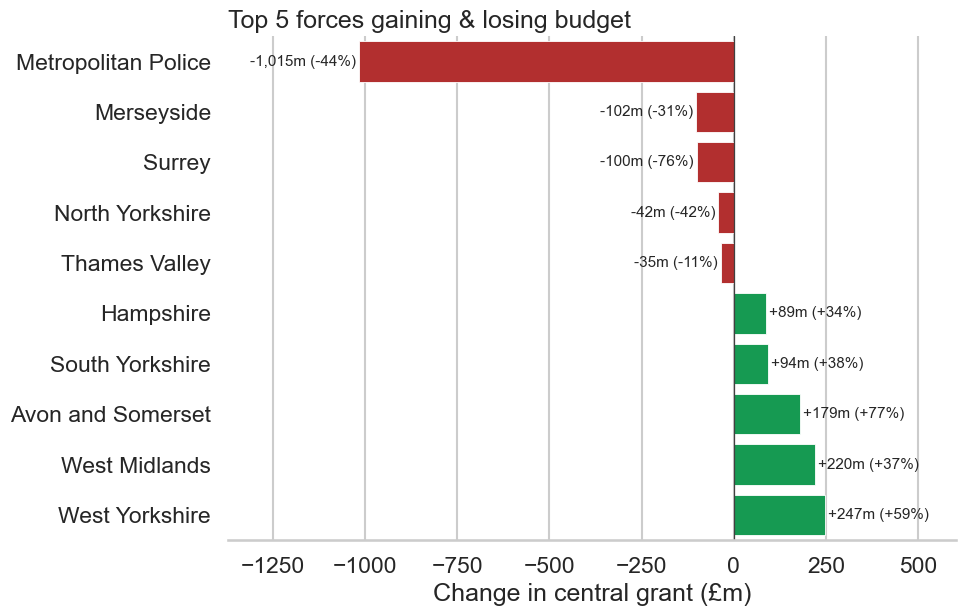

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 5 gainers + top 5 losers by absolute change, ordered for a diverging bar.
top = pl.concat([
    result.sort("delta", descending=True).head(5),
    result.sort("delta").head(5),
]).sort("delta").with_columns([
    (pl.col("delta") / 1e6).alias("delta_m"),
    (pl.col("delta") > 0).alias("gain"),
])
pdf = top.to_pandas()

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(10, 6.5))
sns.barplot(
    data=pdf, y="force", x="delta_m", hue="gain",
    palette={True: "#00b050", False: "#c81919"},
    dodge=False, edgecolor="white", linewidth=0.6, ax=ax,
)
ax.axvline(0, color="0.25", linewidth=0.9)
ax.set_xlabel("Change in central grant (£m)")
ax.set_ylabel("")
ax.set_title("Top 5 forces gaining & losing budget", loc="left")
ax.legend_.remove()

for bar, (_, row) in zip(ax.patches, pdf.iterrows()):
    w = bar.get_width()
    ax.text(w + (8 if w >= 0 else -8), bar.get_y() + bar.get_height() / 2,
            f"{row.delta_m:+,.0f}m ({row.delta_pct:+.0f}%)",
            va="center", ha="left" if w >= 0 else "right", fontsize=11)

pad = pdf["delta_m"].abs().max() * 0.35
ax.set_xlim(pdf["delta_m"].min() - pad, pdf["delta_m"].max() + pad)
sns.despine(left=True)
plt.tight_layout()
plt.savefig("top5_grant_changes.png", dpi=150, bbox_inches="tight")
plt.show()